<a href="https://colab.research.google.com/github/tezendrax/Machine-Learning-Prac/blob/main/Confidence_Interval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

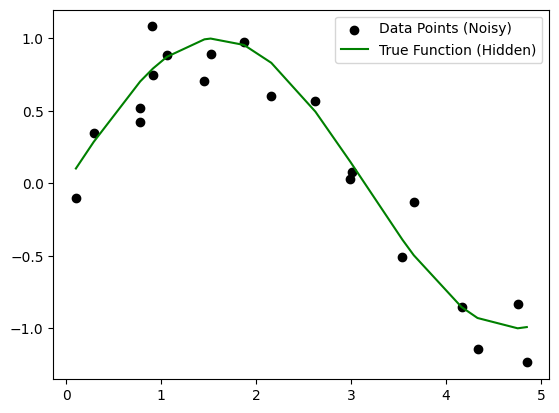

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

# 1) random data
np.random.seed(42)
x = np.sort(np.random.rand(20) * 5) # 20 points between 0 and 5
y_true = np.sin(x)
y_noise = y_true + np.random.normal(0, 0.2, len(x)) # Adding some "messiness"
X = x.reshape(-1, 1)

# 2) Plot it
plt.scatter(x, y_noise, color='black', label='Data Points (Noisy)')
plt.plot(x, y_true, color='green', label='True Function (Hidden)')
plt.legend()
plt.show()

In [ ]:
n_runs = 10
confidence = 0.95
z = norm.ppf(0.5 + confidence / 2)


In [ ]:
x_test = np.linspace(0, 5, 200).reshape(-1, 1)
predictions = []


In [ ]:
for i in range(n_runs):
    y_noisy = y_true + np.random.normal(0, 0.2, len(x)) #mean,SD

    model = LinearRegression()
    model.fit(X, y_noisy)

    y_pred = model.predict(x_test)
    predictions.append(y_pred)


In [ ]:
predictions = np.array(predictions)


In [ ]:
mean_pred = predictions.mean(axis=0)
std_pred = predictions.std(axis=0)

lower = mean_pred - z * std_pred
upper = mean_pred + z * std_pred


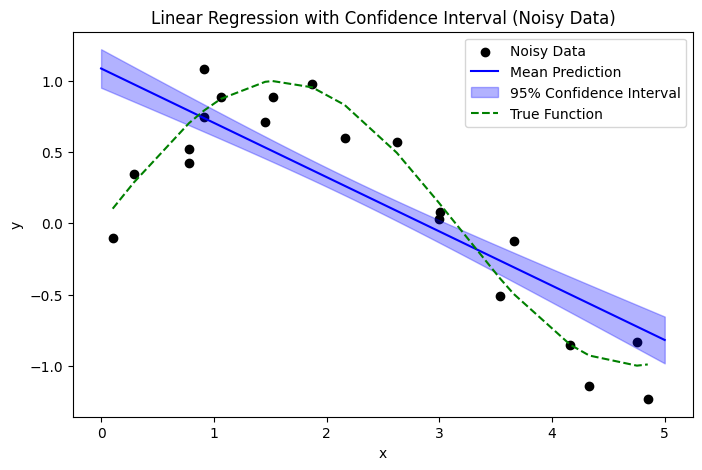

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(x, y_noise, color='black', label='Noisy Data')
plt.plot(x_test, mean_pred, color='blue', label='Mean Prediction')
plt.fill_between(
    x_test.ravel(),
    lower,
    upper,
    color='blue',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.plot(x, y_true, color='green', linestyle='--', label='True Function')

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Confidence Interval (Noisy Data)")
plt.show()
